# Install and Imports Libraries

In [1]:
!nvidia-smi

Wed Nov 19 18:55:30 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.4 MB/s eta 0:00:00


In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models, Model # Moved Model import here
from tensorflow.keras.applications import EfficientNetB3, ResNet50, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import cv2
import shutil
from PIL import Image
import os
from tqdm import tqdm
import random
from sklearn.metrics import classification_report, confusion_matrix

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ismailpromus/skin-diseases-image-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-diseases-image-dataset' dataset.
Path to dataset files: /kaggle/input/skin-diseases-image-dataset


In [10]:
import os

root = "/kaggle/input/skin-diseases-image-dataset"

print("=== LIST root ===")
print(os.listdir(root))

print("\n=== FULL TREE ===")
for r, dirs, files in os.walk(root):
    print("DIR:", r)
    for d in dirs:
        print("  -", d)
    for f in files:
        print("    *", f)

Streaming output truncated to the last 5000 lines.
    * ISIC_0059972.jpg
    * ISIC_0028020.jpg
    * ISIC_0055027.jpg
    * ISIC_0030459.jpg
    * ISIC_0069291.jpg
    * ISIC_0071502.jpg
    * ISIC_0032972.jpg
    * ISIC_0026015.jpg
    * ISIC_0064900.jpg
    * ISIC_0058507.jpg
    * ISIC_0066313.jpg
DIR: /kaggle/input/skin-diseases-image-dataset/IMG_CLASSES/8. Seborrheic Keratoses and other Benign Tumors - 1.8k
    * t-seborrheic-keratoses-smooth-124.jpg
    * 166_1_11.jpg
    * t-epidermal-cyst-118.jpg
    * v-seborrheic-keratoses-smooth-110.jpg
    * v-seborrheic-keratosis-irritated-105.jpg
    * t-seborrheic-keratosis-irritated-3.jpg
    * t-porokeratosis-35.jpg
    * v-seborrheic-keratoses-smooth-20.jpg
    * t-chondrodermatitis-nodularis-51.jpg
    * t-seborrheic-keratoses-smooth-97.jpg
    * t-dermatofibroma-31.jpg
    * t-dermatofibroma-80.jpg
    * t-chondrodermatitis-nodularis-21.jpg
    * t-dermatosis-papulosa-nigra-7.jpg
    * t-dermatofibroma-54.jpg
    * t-keloids-55.jp

In [6]:
print("IMG_CLASSES content:")
print(os.listdir(os.path.join(root, "IMG_CLASSES")))

IMG_CLASSES content:
['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '4. Basal Cell Carcinoma (BCC) 3323', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '5. Melanocytic Nevi (NV) - 7970', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k', '3. Atopic Dermatitis - 1.25k', '6. Benign Keratosis-like Lesions (BKL) 2624', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '2. Melanoma 15.75k']


In [11]:
# ---------- 1. Paths & selected 4 classes (same logic as your script) ----------
DATA_PATH = os.path.join("/kaggle/input/skin-diseases-image-dataset", "IMG_CLASSES")
OUTPUT_ROOT = "/kaggle/working/BALANCED_4_CLASSES"
TRAIN_PATH = os.path.join(OUTPUT_ROOT, "train")
VAL_PATH   = os.path.join(OUTPUT_ROOT, "val")
TEST_PATH  = os.path.join(OUTPUT_ROOT, "test")

SELECTED = {
    "1. Eczema 1677": "Eczema",
    "7. Psoriasis pictures Lichen Planus and related diseases - 2k": "Psoriasis",
    "8. Seborrheic Keratoses and other Benign Tumors - 1.8k": "Benign",
    "2. Melanoma 15.75k": "Melanoma"
}

# safety create
if os.path.exists(OUTPUT_ROOT):
    shutil.rmtree(OUTPUT_ROOT)
os.makedirs(TRAIN_PATH, exist_ok=True)
os.makedirs(VAL_PATH, exist_ok=True)
os.makedirs(TEST_PATH, exist_ok=True)

TARGET_PER_CLASS = 1000
VAL_COUNT = 100
TEST_COUNT = 100

In [12]:
#create balanced small dataset for quick experimentation
for long_name, short_name in SELECTED.items():
    src = os.path.join(DATA_PATH, long_name)
    imgs = [f for f in os.listdir(src) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(imgs)
    train_imgs = imgs[:TARGET_PER_CLASS]
    val_imgs   = imgs[TARGET_PER_CLASS: TARGET_PER_CLASS + VAL_COUNT]
    test_imgs  = imgs[TARGET_PER_CLASS + VAL_COUNT: TARGET_PER_CLASS + VAL_COUNT + TEST_COUNT]
    os.makedirs(os.path.join(TRAIN_PATH, short_name), exist_ok=True)
    os.makedirs(os.path.join(VAL_PATH, short_name), exist_ok=True)
    os.makedirs(os.path.join(TEST_PATH, short_name), exist_ok=True)
    for f in train_imgs:
        shutil.copy(os.path.join(src,f), os.path.join(TRAIN_PATH, short_name, f))
    for f in val_imgs:
        shutil.copy(os.path.join(src,f), os.path.join(VAL_PATH, short_name, f))
    for f in test_imgs:
        shutil.copy(os.path.join(src,f), os.path.join(TEST_PATH, short_name, f))
print("Copied dataset -> Train/Val/Test ready")

Copied dataset -> Train/Val/Test ready


# Image Preprocessing

In [13]:
# preprocessing reduces background cues (color constancy, hair) and crops lesion
IMG_SIZE = 224
def shades_of_gray(img, power=6):
    img = img.astype(np.float32) + 1e-8
    rgb_pow = np.power(img, power)
    v = np.power(np.sum(rgb_pow, axis=(0,1)), 1.0/power)
    scale = v.mean() / v
    out = img * scale
    out = np.clip(out,0,255).astype(np.uint8)
    return out

def remove_hair_dullrazor(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9,9))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, th = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    inpaint = cv2.inpaint(img, th, 1, cv2.INPAINT_TELEA)
    return inpaint

def lesion_square_crop(img, pad=0.12):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_OTSU + cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return cv2.resize(img, (IMG_SIZE,IMG_SIZE))
    c = max(contours, key=cv2.contourArea)
    x,y,w,h = cv2.boundingRect(c)
    cx, cy = x + w//2, y + h//2
    side = int(max(w,h)*(1+pad))
    x1 = max(0, cx - side//2)
    y1 = max(0, cy - side//2)
    x2 = min(img.shape[1], x1 + side)
    y2 = min(img.shape[0], y1 + side)
    crop = img[y1:y2, x1:x2]
    return cv2.resize(crop, (IMG_SIZE,IMG_SIZE))

def too_blurry(img, thresh=25):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var() < thresh

def bad_exposure(img, low=40, high=230):
    v = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)[:,:,2]
    m = np.mean(v)
    return (m < low) or (m > high)

In [14]:
#to save time do a quick pass and skip bad images; keep a log (use a subset if slow)
CLEANED_ROOT = "/kaggle/working/CLEANED_4"
if os.path.exists(CLEANED_ROOT):
    shutil.rmtree(CLEANED_ROOT)
os.makedirs(CLEANED_ROOT, exist_ok=True)

# process train/val/test
for split_src, split_dst in [(TRAIN_PATH, os.path.join(CLEANED_ROOT,'train')),
                             (VAL_PATH, os.path.join(CLEANED_ROOT,'val')),
                             (TEST_PATH, os.path.join(CLEANED_ROOT,'test'))]:
    os.makedirs(split_dst, exist_ok=True)
    for cls in os.listdir(split_src):
        os.makedirs(os.path.join(split_dst, cls), exist_ok=True)
        files = os.listdir(os.path.join(split_src, cls))
        # optional: process only a subset for speed (uncomment to limit)
        # files = files[:500]
        for f in tqdm(files, desc=f"Cleaning {cls}"):
            p = os.path.join(split_src, cls, f)
            try:
                img = cv2.imread(p)[:,:,::-1]  # BGR->RGB
                img = shades_of_gray(img)
                img = remove_hair_dullrazor(img)
                img = lesion_square_crop(img)
                if too_blurry(img) or bad_exposure(img):
                    continue
                outp = os.path.join(split_dst, cls, f)
                cv2.imwrite(outp, img[:,:,::-1])  # save BGR
            except Exception as e:
                # skip a few corrupted files
                continue

print("Cleaning done -> CLEANED_4 ready")

Cleaning Psoriasis: 100%|██████████| 100/100 [00:12<00:00,  8.21it/s]

Cleaning done -> CLEANED_4 ready


In [33]:
# downsample to min class
BALANCED = "/kaggle/working/BALANCED_CLEANED"
if os.path.exists(BALANCED):
    shutil.rmtree(BALANCED)
os.makedirs(BALANCED, exist_ok=True)

counts = {}
for cls in os.listdir(os.path.join(CLEANED_ROOT,'train')):
    counts[cls] = len(os.listdir(os.path.join(CLEANED_ROOT,'train',cls)))
min_count = min(counts.values())
print("Per-class counts (train) before balancing:", counts, "-> downsample to", min_count)

for cls in counts:
    src = os.path.join(CLEANED_ROOT, 'train', cls)
    dst = os.path.join(BALANCED, cls)
    os.makedirs(dst, exist_ok=True)
    imgs = os.listdir(src)
    random.shuffle(imgs)
    for im in imgs[:min_count]:
        shutil.copy(os.path.join(src, im), os.path.join(dst, im))

# copy val/test as-is (they are already small)
VAL_BAL = os.path.join(BALANCED, 'val')
TEST_BAL = os.path.join(BALANCED, 'test')
# create val/test folders structure
for cls in os.listdir(os.path.join(CLEANED_ROOT,'val')):
    os.makedirs(os.path.join(BALANCED, 'val', cls), exist_ok=True)
    for f in os.listdir(os.path.join(CLEANED_ROOT,'val',cls)):
        shutil.copy(os.path.join(CLEANED_ROOT,'val',cls,f), os.path.join(BALANCED,'val',cls,f))
for cls in os.listdir(os.path.join(CLEANED_ROOT,'test')):
    os.makedirs(os.path.join(BALANCED, 'test', cls), exist_ok=True)
    for f in os.listdir(os.path.join(CLEANED_ROOT,'test',cls)):
        shutil.copy(os.path.join(CLEANED_ROOT,'test',cls,f), os.path.join(BALANCED,'test',cls,f))

print("Balanced dataset created at:", BALANCED)

Per-class counts (train) before balancing: {'Benign': 975, 'Melanoma': 924, 'Eczema': 973, 'Psoriasis': 963} -> downsample to 924
Balanced dataset created at: /kaggle/working/BALANCED_CLEANED


In [16]:
#Crash
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# Data Augmentation

In [35]:
# --- FIX STRUCTURE ---
TRAIN_ONLY = "/kaggle/working/BALANCED_TRAIN_ONLY"


if os.path.exists(TRAIN_ONLY):
    shutil.rmtree(TRAIN_ONLY)

os.makedirs(TRAIN_ONLY, exist_ok=True)


for cls in os.listdir(BALANCED):
    if cls.lower() in ["val", "test"]:
        continue
    src = os.path.join(BALANCED, cls)
    dst = os.path.join(TRAIN_ONLY, cls)
    shutil.copytree(src, dst)

print("Train-only folders:", os.listdir(TRAIN_ONLY))

Train-only folders: ['Benign', 'Melanoma', 'Eczema', 'Psoriasis']


In [37]:
TRAIN_DIR = BALANCED              # contains only class folders
VAL_DIR   = os.path.join(BALANCED, "val")
TEST_DIR  = os.path.join(BALANCED, "test")

train_gen = train_datagen.flow_from_directory(
    TRAIN_ONLY,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(BALANCED, "val"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode='categorical',
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(BALANCED, "test"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode='categorical',
    shuffle=False
)


Found 3696 images belonging to 4 classes.
Found 385 images belonging to 4 classes.
Found 390 images belonging to 4 classes.


In [18]:
train_gen.samples, val_gen.samples, test_gen.samples

(4471, 385, 390)

# The Base of Transfer Learning

In [19]:
def build_model(base_fn, num_classes=4, lr=1e-4):
    base = base_fn(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    model = models.Model(base.input, out)
    model.compile(optimizer=Adam(lr), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# DENSENET121 — Strong Medical Baseline

In [38]:
callbacks5 = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6),
    ModelCheckpoint("/content/drive/MyDrive/AI & Data Science/Skin Disease/DENSENET121_model.h5", save_best_only=True, monitor='val_loss')
]

In [39]:
from tensorflow.keras.applications import DenseNet121
model_dense = build_model(DenseNet121, lr=1e-4)
history_dense = model_dense.fit(
    train_gen, validation_data=val_gen, epochs=12, callbacks=callbacks5
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.3431 - loss: 1.4993

116/116 ━━━━━━━━━━━━━━━━━━━━ 129s 814ms/step - accuracy: 0.3440 - loss: 1.4974 - val_accuracy: 0.6234 - val_loss: 0.9082 - learning_rate: 1.0000e-04
Epoch 2/12
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.5871 - loss: 0.9584

116/116 ━━━━━━━━━━━━━━━━━━━━ 54s 468ms/step - accuracy: 0.5871 - loss: 0.9582 - val_accuracy: 0.6571 - val_loss: 0.7914 - learning_rate: 1.0000e-04
Epoch 3/12
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.6213 - loss: 0.8936

116/116 ━━━━━━━━━━━━━━━━━━━━ 54s 463ms/step - accuracy: 0.6213 - loss: 0.8934 - val_accuracy: 0.6701 - val_loss: 0.7381 - learning_rate: 1.0000e-04
Epoch 4/12
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.6383 - loss: 0.8052

116/116 ━━━━━━━━━━━━━━━━━━━━ 54s 462ms/step - accuracy: 0.6382 - loss: 0.8054 - val_accuracy: 0.6779 - val_loss: 0.7257 - learning_rate: 1.0000e-04
Epoch 5/12
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.6538 - loss: 0.8003

116/116 ━━━━━━━━━━━━━━━━━━━━ 54s 462ms/step - accuracy: 0.6537 - loss: 0.8003 - val_accuracy: 0.6961 - val_loss: 0.6988 - learning_rate: 1.0000e-04
Epoch 6/12
116/116 ━━━━━━━━━━━━━━━━━━━━ 51s 441ms/step - accuracy: 0.6504 - loss: 0.7795 - val_accuracy: 0.6675 - val_loss: 0.7254 - learning_rate: 1.0000e-04
Epoch 7/12
116/116 ━━━━━━━━━━━━━━━━━━━━ 52s 449ms/step - accuracy: 0.6748 - loss: 0.7553 - val_accuracy: 0.6883 - val_loss: 0.7006 - learning_rate: 1.0000e-04
Epoch 8/12
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.6609 - loss: 0.7565

116/116 ━━━━━━━━━━━━━━━━━━━━ 54s 464ms/step - accuracy: 0.6610 - loss: 0.7564 - val_accuracy: 0.6857 - val_loss: 0.6937 - learning_rate: 1.0000e-04
Epoch 9/12
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.6883 - loss: 0.7327

116/116 ━━━━━━━━━━━━━━━━━━━━ 60s 516ms/step - accuracy: 0.6882 - loss: 0.7327 - val_accuracy: 0.6961 - val_loss: 0.6747 - learning_rate: 1.0000e-04
Epoch 10/12
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.6766 - loss: 0.7414

116/116 ━━━━━━━━━━━━━━━━━━━━ 59s 506ms/step - accuracy: 0.6767 - loss: 0.7413 - val_accuracy: 0.7039 - val_loss: 0.6682 - learning_rate: 1.0000e-04
Epoch 11/12
116/116 ━━━━━━━━━━━━━━━━━━━━ 51s 441ms/step - accuracy: 0.6780 - loss: 0.7277 - val_accuracy: 0.7065 - val_loss: 0.6711 - learning_rate: 1.0000e-04
Epoch 12/12
116/116 ━━━━━━━━━━━━━━━━━━━━ 56s 486ms/step - accuracy: 0.6760 - loss: 0.7261 - val_accuracy: 0.7039 - val_loss: 0.6861 - learning_rate: 1.0000e-04


# DenseNet169 Model

In [42]:
from tensorflow.keras.applications import DenseNet169
model_dense = build_model(DenseNet169)
history_dense169 = model_dense.fit(
    train_gen, validation_data=val_gen, epochs=20,
    callbacks=[
        EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6),
        ModelCheckpoint("/content/drive/MyDrive/AI & Data Science/Skin Disease/DENSENET169_model.h5",
                        save_best_only=True, monitor='val_loss')
    ]
)

Epoch 1/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.3809 - loss: 1.3785

116/116 ━━━━━━━━━━━━━━━━━━━━ 143s 922ms/step - accuracy: 0.3818 - loss: 1.3767 - val_accuracy: 0.6234 - val_loss: 0.8637 - learning_rate: 1.0000e-04
Epoch 2/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.5981 - loss: 0.9219

116/116 ━━━━━━━━━━━━━━━━━━━━ 55s 475ms/step - accuracy: 0.5982 - loss: 0.9217 - val_accuracy: 0.6545 - val_loss: 0.7555 - learning_rate: 1.0000e-04
Epoch 3/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.6381 - loss: 0.8358

116/116 ━━━━━━━━━━━━━━━━━━━━ 55s 474ms/step - accuracy: 0.6381 - loss: 0.8357 - val_accuracy: 0.6623 - val_loss: 0.7401 - learning_rate: 1.0000e-04
Epoch 4/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.6629 - loss: 0.7815

116/116 ━━━━━━━━━━━━━━━━━━━━ 54s 469ms/step - accuracy: 0.6628 - loss: 0.7816 - val_accuracy: 0.6779 - val_loss: 0.7189 - learning_rate: 1.0000e-04
Epoch 5/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.6751 - loss: 0.7444

...

116/116 ━━━━━━━━━━━━━━━━━━━━ 55s 470ms/step - accuracy: 0.7086 - loss: 0.6515 - val_accuracy: 0.7065 - val_loss: 0.6630 - learning_rate: 1.0000e-04
Epoch 14/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 52s 445ms/step - accuracy: 0.7122 - loss: 0.6451 - val_accuracy: 0.6935 - val_loss: 0.6904 - learning_rate: 1.0000e-04
Epoch 15/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.7262 - loss: 0.6381

116/116 ━━━━━━━━━━━━━━━━━━━━ 54s 469ms/step - accuracy: 0.7262 - loss: 0.6382 - val_accuracy: 0.7117 - val_loss: 0.6596 - learning_rate: 1.0000e-04
Epoch 16/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.7218 - loss: 0.6392

116/116 ━━━━━━━━━━━━━━━━━━━━ 55s 476ms/step - accuracy: 0.7217 - loss: 0.6393 - val_accuracy: 0.7247 - val_loss: 0.6593 - learning_rate: 1.0000e-04
Epoch 17/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 52s 445ms/step - accuracy: 0.7282 - loss: 0.6271 - val_accuracy: 0.7117 - val_loss: 0.6654 - learning_rate: 1.0000e-04
Epoch 18/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.7148 - loss: 0.6388

116/116 ━━━━━━━━━━━━━━━━━━━━ 54s 468ms/step - accuracy: 0.7149 - loss: 0.6388 - val_accuracy: 0.7091 - val_loss: 0.6554 - learning_rate: 1.0000e-04
Epoch 19/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.7331 - loss: 0.6049

116/116 ━━━━━━━━━━━━━━━━━━━━ 82s 467ms/step - accuracy: 0.7330 - loss: 0.6050 - val_accuracy: 0.7169 - val_loss: 0.6422 - learning_rate: 1.0000e-04
Epoch 20/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 51s 440ms/step - accuracy: 0.7324 - loss: 0.6169 - val_accuracy: 0.6961 - val_loss: 0.6628 - learning_rate: 1.0000e-04


In [47]:
test_loss, test_acc = model_dense.evaluate(test_gen)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.7720 - loss: 0.5805 
Test Loss: 0.590239942073822
Test Accuracy: 0.7384615540504456


In [56]:
#fine-tuning
# 1) فك آخر 50 طبقة فقط من DenseNet169
fine_tune_at = len(model_dense.layers) - 50

for layer in model_dense.layers[:fine_tune_at]:
    layer.trainable = False

for layer in model_dense.layers[fine_tune_at:]:
    layer.trainable = True

# 2) إعادة الكومبايل بليرنينج ريت قليل جداً
from tensorflow.keras.optimizers import Adam
model_dense.compile(
    optimizer=Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3) تدريب الـ Fine-tuning
history_ft = model_dense.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[
        EarlyStopping(patience=6, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7),
        ModelCheckpoint("/content/drive/MyDrive/AI & Data Science/Skin Disease/DENSENET169_FT_model.h5",
                        save_best_only=True, monitor='val_loss')
    ]
)

Epoch 1/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 873ms/step - accuracy: 0.7188 - loss: 0.6516

116/116 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.7188 - loss: 0.6515 - val_accuracy: 0.7273 - val_loss: 0.6803 - learning_rate: 1.0000e-05
Epoch 2/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.7253 - loss: 0.6290

116/116 ━━━━━━━━━━━━━━━━━━━━ 57s 485ms/step - accuracy: 0.7254 - loss: 0.6288 - val_accuracy: 0.7325 - val_loss: 0.6766 - learning_rate: 1.0000e-05
Epoch 3/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 54s 461ms/step - accuracy: 0.7385 - loss: 0.6220 - val_accuracy: 0.7299 - val_loss: 0.6768 - learning_rate: 1.0000e-05
Epoch 4/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.7443 - loss: 0.5947

116/116 ━━━━━━━━━━━━━━━━━━━━ 56s 483ms/step - accuracy: 0.7442 - loss: 0.5947 - val_accuracy: 0.7299 - val_loss: 0.6697 - learning_rate: 1.0000e-05
Epoch 5/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 54s 461ms/step - accuracy: 0.7580 - loss: 0.5784 - val_accuracy: 0.7325 - val_loss: 0.6706 - learning_rate: 1.0000e-05
Epoch 6/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.7528 - loss: 0.5828

116/116 ━━━━━━━━━━━━━━━━━━━━ 57s 489ms/step - accuracy: 0.7527 - loss: 0.5829 - val_accuracy: 0.7351 - val_loss: 0.6656 - learning_rate: 1.0000e-05
Epoch 7/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.7468 - loss: 0.5883

116/116 ━━━━━━━━━━━━━━━━━━━━ 58s 500ms/step - accuracy: 0.7467 - loss: 0.5884 - val_accuracy: 0.7221 - val_loss: 0.6627 - learning_rate: 1.0000e-05
Epoch 8/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.7551 - loss: 0.5745

116/116 ━━━━━━━━━━━━━━━━━━━━ 57s 488ms/step - accuracy: 0.7551 - loss: 0.5745 - val_accuracy: 0.7273 - val_loss: 0.6591 - learning_rate: 1.0000e-05
Epoch 9/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.7504 - loss: 0.5775

116/116 ━━━━━━━━━━━━━━━━━━━━ 57s 492ms/step - accuracy: 0.7504 - loss: 0.5776 - val_accuracy: 0.7273 - val_loss: 0.6539 - learning_rate: 1.0000e-05
Epoch 10/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.7535 - loss: 0.5740

116/116 ━━━━━━━━━━━━━━━━━━━━ 57s 487ms/step - accuracy: 0.7535 - loss: 0.5741 - val_accuracy: 0.7273 - val_loss: 0.6529 - learning_rate: 1.0000e-05


In [57]:
test_loss, test_acc = model_dense.evaluate(test_gen)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7743 - loss: 0.5358
Test Loss: 0.580578088760376
Test Accuracy: 0.728205144405365


# Efficintnet model

In [49]:
from tensorflow.keras.applications import EfficientNetB3

model_effnet = build_model(EfficientNetB3)

In [50]:
history_effnetB3 = model_effnet.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[
        EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6),
        ModelCheckpoint(
            "/content/drive/MyDrive/AI & Data Science/Skin Disease/EFFNETB3_model.h5",
            save_best_only=True,
            monitor='val_loss'
        )
    ]
)

Epoch 1/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 988ms/step - accuracy: 0.2556 - loss: 1.4022

116/116 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.2558 - loss: 1.4021 - val_accuracy: 0.2701 - val_loss: 1.3628 - learning_rate: 1.0000e-04
Epoch 2/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.2658 - loss: 1.3853

116/116 ━━━━━━━━━━━━━━━━━━━━ 54s 464ms/step - accuracy: 0.2660 - loss: 1.3853 - val_accuracy: 0.4390 - val_loss: 1.3491 - learning_rate: 1.0000e-04
Epoch 3/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.3059 - loss: 1.3688

116/116 ━━━━━━━━━━━━━━━━━━━━ 55s 471ms/step - accuracy: 0.3059 - loss: 1.3687 - val_accuracy: 0.3532 - val_loss: 1.3307 - learning_rate: 1.0000e-04
Epoch 4/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.3240 - loss: 1.3534

116/116 ━━━━━━━━━━━━━━━━━━━━ 53s 460ms/step - accuracy: 0.3240 - loss: 1.3534 - val_accuracy: 0.3532 - val_loss: 1.3276 - learning_rate: 1.0000e-04
Epoch 5/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 51s 441ms/step - accuracy: 0.3268 - loss: 1.3496 - val_accuracy: 0.3299 - val_loss: 1.3307 - learning_rate: 1.0000e-04
Epoch 6/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.3313 - loss: 1.3432

116/116 ━━━━━━━━━━━━━━━━━━━━ 54s 464ms/step - accuracy: 0.3312 - loss: 1.3432 - val_accuracy: 0.3455 - val_loss: 1.3082 - learning_rate: 1.0000e-04
Epoch 7/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.3363 - loss: 1.3385

116/116 ━━━━━━━━━━━━━━━━━━━━ 54s 464ms/step - accuracy: 0.3363 - loss: 1.3385 - val_accuracy: 0.3844 - val_loss: 1.2961 - learning_rate: 1.0000e-04
Epoch 8/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.3589 - loss: 1.3284

116/116 ━━━━━━━━━━━━━━━━━━━━ 53s 461ms/step - accuracy: 0.3589 - loss: 1.3283 - val_accuracy: 0.3714 - val_loss: 1.2924 - learning_rate: 1.0000e-04
Epoch 9/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.3452 - loss: 1.3296

116/116 ━━━━━━━━━━━━━━━━━━━━ 54s 467ms/step - accuracy: 0.3452 - loss: 1.3296 - val_accuracy: 0.3792 - val_loss: 1.2845 - learning_rate: 1.0000e-04
Epoch 10/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 51s 444ms/step - accuracy: 0.3597 - loss: 1.3216 - val_accuracy: 0.3558 - val_loss: 1.3269 - learning_rate: 1.0000e-04
Epoch 11/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 50s 434ms/step - accuracy: 0.3525 - loss: 1.3330 - val_accuracy: 0.3481 - val_loss: 1.2961 - learning_rate: 1.0000e-04
Epoch 12/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 50s 435ms/step - accuracy: 0.3633 - loss: 1.3122 - val_accuracy: 0.3455 - val_loss: 1.3084 - learning_rate: 1.0000e-04


In [51]:
test_loss, test_acc = model_effnet.evaluate(test_gen)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.3323 - loss: 1.3151
Test Loss: 1.2882426977157593
Test Accuracy: 0.38717949390411377


# RESNET MODEL

In [67]:
from tensorflow.keras.applications import ResNet50
model_res = build_model(ResNet50)
history_res = model_res.fit(
    train_gen, validation_data=val_gen, epochs=20,
    callbacks=[
        EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6),
        ModelCheckpoint("/content/drive/MyDrive/AI & Data Science/Skin Disease/RESNET121_model2.h5", save_best_only=True, monitor='val_loss')
    ]
)

Epoch 1/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.2450 - loss: 1.5771

116/116 ━━━━━━━━━━━━━━━━━━━━ 86s 629ms/step - accuracy: 0.2450 - loss: 1.5767 - val_accuracy: 0.2545 - val_loss: 1.3812 - learning_rate: 1.0000e-04
Epoch 2/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.2714 - loss: 1.4630

116/116 ━━━━━━━━━━━━━━━━━━━━ 55s 473ms/step - accuracy: 0.2714 - loss: 1.4630 - val_accuracy: 0.2571 - val_loss: 1.3708 - learning_rate: 1.0000e-04
Epoch 3/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.2650 - loss: 1.4441

116/116 ━━━━━━━━━━━━━━━━━━━━ 55s 473ms/step - accuracy: 0.2650 - loss: 1.4440 - val_accuracy: 0.3740 - val_loss: 1.3617 - learning_rate: 1.0000e-04
Epoch 4/20
 41/116 ━━━━━━━━━━━━━━━━━━━━ 33s 446ms/step - accuracy: 0.2638 - loss: 1.4047

KeyboardInterrupt: 

In [58]:
test_loss, test_acc = model_res.evaluate(test_gen)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.0714 - loss: 1.7033
Test Loss: 1.6191049814224243
Test Accuracy: 0.25128206610679626


# HYBRID MODEL - EfficientNetB3 Backbone + CBAM Attention Module

In [ ]:
callbacks2 = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6),
    ModelCheckpoint("/content/drive/MyDrive/AI & Data Science/Skin Disease/HYBIRD_model.h5", save_best_only=True, monitor='val_loss')
]

In [ ]:
#CBAM BLOCK — small, clean, readable
import keras.backend as K
def cbam_block(x, ratio=8):
    # ===== Channel Attention =====
    channel = x.shape[-1]

    avg_pool = layers.GlobalAveragePooling2D()(x)
    avg_pool = layers.Reshape((1,1,channel))(avg_pool)

    max_pool = layers.GlobalMaxPooling2D()(x)
    max_pool = layers.Reshape((1,1,channel))(max_pool)

    shared_dense1 = layers.Dense(channel // ratio, activation="relu")
    shared_dense2 = layers.Dense(channel)

    avg_out = shared_dense2(shared_dense1(avg_pool))
    max_out = shared_dense2(shared_dense1(max_pool))

    channel_attention = layers.Activation("sigmoid")(layers.Add()([avg_out, max_out]))
    x = layers.Multiply()([x, channel_attention])

    # ===== Spatial Attention =====
    # Explicitly specify output_shape for Lambda layers
    # Using tf.reduce_mean and tf.reduce_max instead of K.mean/K.max for Keras 3 compatibility
    avg_spatial = layers.Lambda(lambda z: tf.reduce_mean(z, axis=3, keepdims=True), output_shape=lambda input_shape: input_shape[:-1] + (1,))(x)
    max_spatial = layers.Lambda(lambda z: tf.reduce_max(z, axis=3, keepdims=True), output_shape=lambda input_shape: input_shape[:-1] + (1,))(x)
    concat = layers.Concatenate()([avg_spatial, max_spatial])

    spatial_attention = layers.Conv2D(1, kernel_size=7, padding="same", activation="sigmoid")(concat)
    x = layers.Multiply()([x, spatial_attention])

    return x

In [ ]:
#Hybrid Base Model (EfficientNetB3 + CBAM)
def build_hybrid_model(img_size=224, num_classes=4):
    # backbone
    effnet = tf.keras.applications.EfficientNetB3(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3)
    )

    effnet.trainable = False  # Stage 1

    x = effnet.output                    # feature map
    x = cbam_block(x)                    # CBAM هنا
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=effnet.input, outputs=out, name="Hybrid_EffNet_CBAM")
    return model, effnet

In [ ]:
#Train Stage 1 (Head only)
hybrid_model, effnet_backbone_instance = build_hybrid_model(img_size=224, num_classes=4)

hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_h1 = hybrid_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=12,
    callbacks=callbacks2
)

Epoch 1/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 781ms/step - accuracy: 0.2597 - loss: 1.3872

63/63 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.2597 - loss: 1.3872 - val_accuracy: 0.2625 - val_loss: 1.3835 - learning_rate: 1.0000e-04
Epoch 2/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.2766 - loss: 1.3834

63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 351ms/step - accuracy: 0.2766 - loss: 1.3834 - val_accuracy: 0.2625 - val_loss: 1.3806 - learning_rate: 1.0000e-04
Epoch 3/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.3146 - loss: 1.3798

63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 383ms/step - accuracy: 0.3145 - loss: 1.3798 - val_accuracy: 0.3700 - val_loss: 1.3748 - learning_rate: 1.0000e-04
Epoch 4/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.2875 - loss: 1.3760

63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 349ms/step - accuracy: 0.2877 - loss: 1.3759 - val_accuracy: 0.2675 - val_loss: 1.3707 - learning_rate: 1.0000e-04
Epoch 5/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.3006 - loss: 1.3719

...

63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 350ms/step - accuracy: 0.3058 - loss: 1.3683 - val_accuracy: 0.2825 - val_loss: 1.3629 - learning_rate: 1.0000e-04
Epoch 8/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.3304 - loss: 1.3549

63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 353ms/step - accuracy: 0.3304 - loss: 1.3549 - val_accuracy: 0.3375 - val_loss: 1.3565 - learning_rate: 1.0000e-04
Epoch 9/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.3334 - loss: 1.3594

63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 351ms/step - accuracy: 0.3334 - loss: 1.3594 - val_accuracy: 0.3025 - val_loss: 1.3546 - learning_rate: 1.0000e-04
Epoch 10/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.3223 - loss: 1.3553

63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 350ms/step - accuracy: 0.3222 - loss: 1.3554 - val_accuracy: 0.3650 - val_loss: 1.3502 - learning_rate: 1.0000e-04
Epoch 11/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.3245 - loss: 1.3612

63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 355ms/step - accuracy: 0.3246 - loss: 1.3611 - val_accuracy: 0.3150 - val_loss: 1.3482 - learning_rate: 1.0000e-04
Epoch 12/12
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 324ms/step - accuracy: 0.3305 - loss: 1.3573 - val_accuracy: 0.3125 - val_loss: 1.3521 - learning_rate: 1.0000e-04


In [ ]:
#fine tuning
# استخراج الـ backbone الحقيقي
backbone = effnet_backbone_instance

print("Backbone found:", backbone.name)

# قفل كل الطبقات الأول
for layer in backbone.layers:
    layer.trainable = False

# افتح آخر 50 طبقة فقط
for layer in backbone.layers[-50:]:
    layer.trainable = True

# إعادة Compile
hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_h2 = hybrid_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=8,
    callbacks=[
        EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6),
        ModelCheckpoint("/content/drive/MyDrive/AI & Data Science/Skin Disease/HYBRID_FINAL_model.h5", save_best_only=True, monitor='val_loss')
    ]
)

Backbone found: efficientnetb3
Epoch 1/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 739ms/step - accuracy: 0.2802 - loss: 1.3792

63/63 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.2805 - loss: 1.3791 - val_accuracy: 0.2550 - val_loss: 1.4492 - learning_rate: 1.0000e-05
Epoch 2/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.3113 - loss: 1.3634

63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 380ms/step - accuracy: 0.3114 - loss: 1.3634 - val_accuracy: 0.2575 - val_loss: 1.3985 - learning_rate: 1.0000e-05
Epoch 3/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.3283 - loss: 1.3538

63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 441ms/step - accuracy: 0.3282 - loss: 1.3538 - val_accuracy: 0.2925 - val_loss: 1.3687 - learning_rate: 1.0000e-05
Epoch 4/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.3202 - loss: 1.3510

63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 378ms/step - accuracy: 0.3202 - loss: 1.3509 - val_accuracy: 0.3325 - val_loss: 1.3463 - learning_rate: 1.0000e-05
Epoch 5/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.3359 - loss: 1.3394

63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 378ms/step - accuracy: 0.3361 - loss: 1.3393 - val_accuracy: 0.3300 - val_loss: 1.3431 - learning_rate: 1.0000e-05
Epoch 6/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.3321 - loss: 1.3263

63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 356ms/step - accuracy: 0.3322 - loss: 1.3263 - val_accuracy: 0.3625 - val_loss: 1.3198 - learning_rate: 1.0000e-05
Epoch 7/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.3427 - loss: 1.3141

63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 385ms/step - accuracy: 0.3428 - loss: 1.3140 - val_accuracy: 0.3725 - val_loss: 1.3013 - learning_rate: 1.0000e-05
Epoch 8/8
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.3490 - loss: 1.3145

63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 380ms/step - accuracy: 0.3492 - loss: 1.3144 - val_accuracy: 0.3925 - val_loss: 1.2794 - learning_rate: 1.0000e-05


# MobilNet Model

In [59]:
from tensorflow.keras.applications import MobileNetV3Large
model_dense = build_model(MobileNetV3Large)
history_dense = model_dense.fit(
    train_gen, validation_data=val_gen, epochs=20,
    callbacks=[
        EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6),
        ModelCheckpoint("/content/drive/MyDrive/AI & Data Science/Skin Disease/MOBILNET_model.h5", save_best_only=True, monitor='val_loss')
    ]
)

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 750ms/step - accuracy: 0.2605 - loss: 1.4405

116/116 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.2605 - loss: 1.4405 - val_accuracy: 0.2571 - val_loss: 1.3864 - learning_rate: 1.0000e-04
Epoch 2/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.2649 - loss: 1.4324

116/116 ━━━━━━━━━━━━━━━━━━━━ 53s 453ms/step - accuracy: 0.2648 - loss: 1.4324 - val_accuracy: 0.3896 - val_loss: 1.3815 - learning_rate: 1.0000e-04
Epoch 3/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.2662 - loss: 1.4193

116/116 ━━━━━━━━━━━━━━━━━━━━ 52s 445ms/step - accuracy: 0.2660 - loss: 1.4194 - val_accuracy: 0.2545 - val_loss: 1.3746 - learning_rate: 1.0000e-04
Epoch 4/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.2616 - loss: 1.4128

116/116 ━━━━━━━━━━━━━━━━━━━━ 51s 436ms/step - accuracy: 0.2616 - loss: 1.4128 - val_accuracy: 0.2623 - val_loss: 1.3738 - learning_rate: 1.0000e-04
Epoch 5/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.2681 - loss: 1.4081

...

116/116 ━━━━━━━━━━━━━━━━━━━━ 52s 445ms/step - accuracy: 0.2831 - loss: 1.3836 - val_accuracy: 0.3351 - val_loss: 1.3511 - learning_rate: 1.0000e-04
Epoch 14/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 51s 438ms/step - accuracy: 0.2932 - loss: 1.3712 - val_accuracy: 0.3117 - val_loss: 1.3558 - learning_rate: 1.0000e-04
Epoch 15/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.2820 - loss: 1.3746

116/116 ━━━━━━━━━━━━━━━━━━━━ 52s 447ms/step - accuracy: 0.2822 - loss: 1.3745 - val_accuracy: 0.3299 - val_loss: 1.3510 - learning_rate: 1.0000e-04
Epoch 16/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 50s 429ms/step - accuracy: 0.2981 - loss: 1.3741 - val_accuracy: 0.3455 - val_loss: 1.3552 - learning_rate: 1.0000e-04
Epoch 17/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.2849 - loss: 1.3730

116/116 ━━━━━━━━━━━━━━━━━━━━ 51s 433ms/step - accuracy: 0.2850 - loss: 1.3730 - val_accuracy: 0.2649 - val_loss: 1.3470 - learning_rate: 1.0000e-04
Epoch 18/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 51s 438ms/step - accuracy: 0.3164 - loss: 1.3620 - val_accuracy: 0.2597 - val_loss: 1.3484 - learning_rate: 1.0000e-04
Epoch 19/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.3131 - loss: 1.3661

116/116 ━━━━━━━━━━━━━━━━━━━━ 53s 454ms/step - accuracy: 0.3131 - loss: 1.3661 - val_accuracy: 0.4156 - val_loss: 1.3401 - learning_rate: 1.0000e-04
Epoch 20/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.3079 - loss: 1.3636

116/116 ━━━━━━━━━━━━━━━━━━━━ 51s 444ms/step - accuracy: 0.3079 - loss: 1.3636 - val_accuracy: 0.3558 - val_loss: 1.3393 - learning_rate: 1.0000e-04


# Ensemble Learning

In [8]:
import tensorflow as tf
import numpy as np

# Load models (WITHOUT compile)
dense121 = tf.keras.models.load_model("/content/drive/MyDrive/AI & Data Science/Skin Disease/DENSENET121_model.h5", compile=False)
dense169 = tf.keras.models.load_model("/content/drive/MyDrive/AI & Data Science/Skin Disease/DENSENET169_FT_model.h5", compile=False)
effnet50 = tf.keras.models.load_model("/content/drive/MyDrive/AI & Data Science/Skin Disease/EFFNETB3_model.h5", compile=False)

IMG_SIZE = 224

def preprocess(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img = tf.keras.utils.img_to_array(img) / 255.0
    return np.expand_dims(img, axis=0)


In [9]:
#Weighted Ensemble Prediction
def ensemble_predict(img_path):
    img = preprocess(img_path)

    p169 = dense169.predict(img)   # 55%
    p121 = dense121.predict(img)   # 30%
    p50  = effnet50.predict(img)   # 15%

    final_pred = (0.55 * p169) + (0.30 * p121) + (0.15 * p50)
    cls = np.argmax(final_pred, axis=1)[0]

    return cls, final_pred

# Grad-CAM Ensemble

In [19]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Grad-CAM for model
def grad_cam(model, img_array, last_conv_layer=None):

    # Auto-detect last conv layer
    if last_conv_layer is None:
        for layer in reversed(model.layers):
            if len(layer.output.shape) == 4:
                last_conv_layer = layer.name
                break
    print(f"  [DEBUG] Using last conv layer: {last_conv_layer} for model {model.name}")

    if last_conv_layer is None:
        print(f"  [ERROR] No convolutional layer found for model {model.name}")
        return None # Return None if no conv layer is found

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        if tf.reduce_any(tf.math.is_nan(preds)) or tf.reduce_any(tf.math.is_inf(preds)):
            print(f"  [WARNING] NaNs or Infs detected in predictions for model {model.name}. Returning None for heatmap.")
            return None
        top_class = tf.argmax(preds[0])
        loss = preds[:, top_class]

    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    conv_out = conv_out[0]

    heatmap = tf.tensordot(conv_out, pooled, axes=[2,0])
    heatmap = tf.nn.relu(heatmap)

    # Normalize properly
    max_val = tf.reduce_max(heatmap)
    if max_val == 0.0:
        print(f"  [WARNING] Max heatmap value is 0 for model {model.name}. Returning None for heatmap.")
        return None

    heatmap = heatmap / (max_val + 1e-8)
    print(f"  [DEBUG] Heatmap shape for {model.name}: {heatmap.shape}, dtype: {heatmap.dtype}, min: {tf.reduce_min(heatmap)}, max: {tf.reduce_max(heatmap)}")

    return heatmap.numpy()

In [23]:
# Ensemble Grad-CAM function
def ensemble_gradcam(img_path):

    img = preprocess(img_path)  # Your model preprocessing

    print("\n[DEBUG] Generating Grad-CAM for DenseNet169...")
    cam_169 = grad_cam(dense169, img)
    print(f"[DEBUG] DenseNet169 CAM result type: {type(cam_169)}")

    print("\n[DEBUG] Generating Grad-CAM for DenseNet121...")
    cam_121 = grad_cam(dense121, img)
    print(f"[DEBUG] DenseNet121 CAM result type: {type(cam_121)}")

    print("\n[DEBUG] Generating Grad-CAM for EfficientNetB3...")
    cam_50  = grad_cam(effnet50, img)
    print(f"[DEBUG] EfficientNetB3 CAM result type: {type(cam_50)}")

    # Check if any CAM is None
    if cam_169 is None or cam_121 is None or cam_50 is None:
        print("[ERROR] One or more Grad-CAM heatmaps are invalid (None). Cannot compute ensemble CAM.")
        return np.zeros((IMG_SIZE, IMG_SIZE)) # Return a black image or handle gracefully

    # SAME weights as your ensemble
    ensemble_cam = (
        0.55 * cam_169 +
        0.30 * cam_121 +
        0.15 * cam_50
    )

    print(f"[DEBUG] Ensemble CAM shape before resize: {ensemble_cam.shape}, dtype: {ensemble_cam.dtype}, min: {np.min(ensemble_cam)}, max: {np.max(ensemble_cam)}")

    # Check if ensemble_cam is valid for resize
    if ensemble_cam.shape[0] == 0 or ensemble_cam.shape[1] == 0 or np.all(ensemble_cam == 0):
        print("[ERROR] Ensemble CAM is empty or all zeros. Cannot resize.")
        return np.zeros((IMG_SIZE, IMG_SIZE)) # Return a black image to prevent error

    # Explicitly cast to float32 for OpenCV compatibility
    ensemble_cam = ensemble_cam.astype(np.float32)
    ensemble_cam = cv2.resize(ensemble_cam, (224, 224))
    ensemble_cam = ensemble_cam / (ensemble_cam.max() + 1e-8)

    return ensemble_cam

In [24]:
#  Final Visualization Function
def show_ensemble_gradcam(img_path):

    cam = ensemble_gradcam(img_path)

    # Load original image
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Real Grad-CAM heatmap (JET colormap)
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam),
        cv2.COLORMAP_JET
    )
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Perfect overlay
    superimposed = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    # === Plot === #
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Ensemble Grad-CAM (Corrected)")
    plt.imshow(superimposed)
    plt.axis("off")

    plt.show()

In [35]:
img_path = "/content/ISIC_6652978.jpg"

cls, prob = ensemble_predict(img_path)
CLASS_NAMES = ["Eczema", "Psoriasis", "Benign Tumors", "Melanoma"]


print("Predicted Class:", CLASS_NAMES[cls])
print("Class Probabilities:", prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Class: Benign Tumors
Class Probabilities: [[0.03036351 0.03111791 0.9028924  0.03562616]]



[DEBUG] Generating Grad-CAM for DenseNet169...
  [DEBUG] Using last conv layer: relu for model functional_6
  [DEBUG] Heatmap shape for functional_6: (7, 7), dtype: <dtype: 'float16'>, min: 0.0, max: 1.0
[DEBUG] DenseNet169 CAM result type: <class 'numpy.ndarray'>

[DEBUG] Generating Grad-CAM for DenseNet121...
  [DEBUG] Using last conv layer: relu for model functional_4
  [DEBUG] Heatmap shape for functional_4: (7, 7), dtype: <dtype: 'float16'>, min: 0.09625244140625, max: 1.0
[DEBUG] DenseNet121 CAM result type: <class 'numpy.ndarray'>

[DEBUG] Generating Grad-CAM for EfficientNetB3...
  [DEBUG] Using last conv layer: top_activation for model functional_8
  [DEBUG] Heatmap shape for functional_8: (7, 7), dtype: <dtype: 'float16'>, min: 0.0, max: 1.0
[DEBUG] EfficientNetB3 CAM result type: <class 'numpy.ndarray'>
[DEBUG] Ensemble CAM shape before resize: (7, 7), dtype: float16, min: 0.036956787109375, max: 0.97705078125


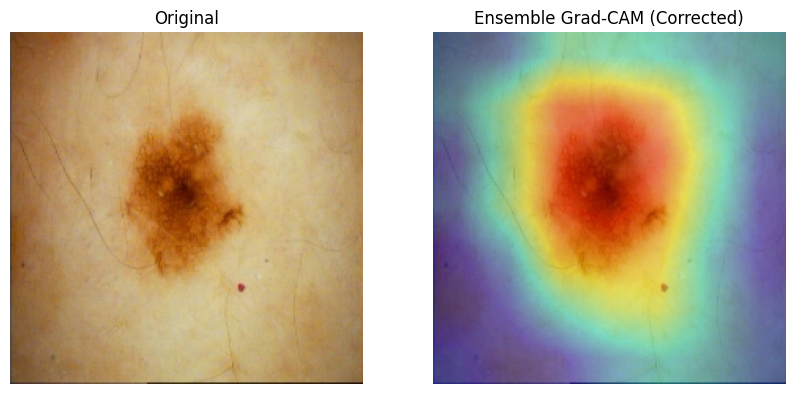

In [36]:
show_ensemble_gradcam(img_path)

# Visualization

/tmp/ipython-input-3100544114.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=df_acc, palette='viridis')


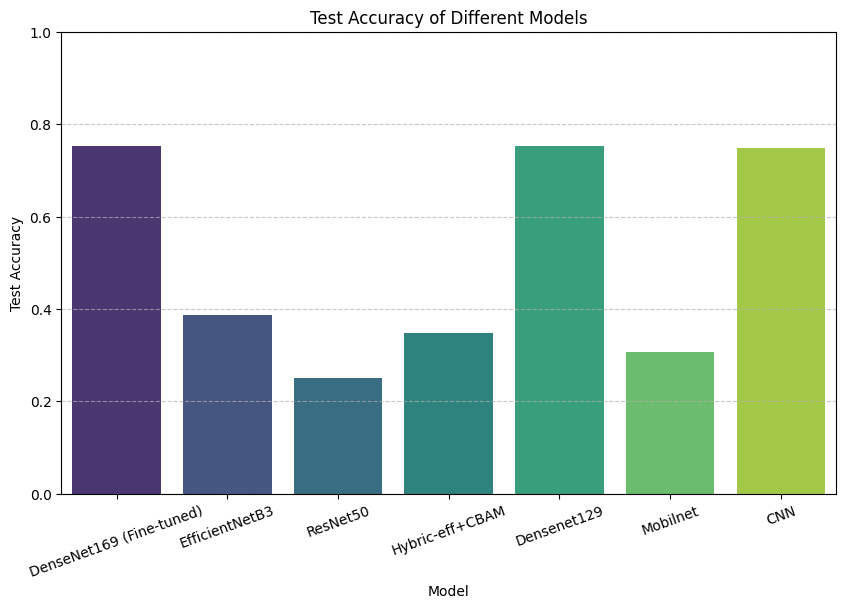

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get the accuracies from the latest executed cells
densenet169_acc = 0.728205144405365 # From cell TN5o1NVP6aJh
efficientnetb3_acc = 0.38717949390411377 # From cell YRVWJ2mEpp1y
resnet50_acc = 0.25128206610679626 # From cell 4K5bhAoK0iGQ
hybrid_acc = 0.3490
densenet169_acc =0.7535
mobilnet_acc = 0.3079
CNN = 0.7483

# Create a DataFrame for plotting
accuracies = {
    'Model': ['DenseNet169 (Fine-tuned)', 'EfficientNetB3', 'ResNet50', 'Hybric-eff+CBAM', 'Densenet129', 'Mobilnet', 'CNN'],
    'Accuracy': [densenet169_acc, efficientnetb3_acc, resnet50_acc, hybrid_acc, densenet169_acc, mobilnet_acc, CNN]
}
df_acc = pd.DataFrame(accuracies)

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=df_acc, palette='viridis')
plt.title('Test Accuracy of Different Models')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1) # Set y-axis limit from 0 to 1 for accuracy
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()